# 에코팜 테마파크 AI 응급예측 모델 — 테스트 결과 리포트

| 항목 | 내용 |
|---|---|
| 데이터 | `final_data_ecofarm.csv` (21,900건, 2025-08-01 ~ 2026-07-31) |
| 모델 | LightGBM 3단계 캐스케이드 |
| 테스트 기간 | 2026-07-01 ~ 2026-07-31 (1,860건) |
| 응급 비율 | 3.82% (836건 / 21,900건) |

---


## 1. 데이터 분할 및 응급 현황

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('final_data_ecofarm.csv')
df['date'] = pd.to_datetime(df['date'])

splits = {'Train':'< 2026-05-01','Val':'2026-05-01 ~ 2026-07-01','Test':'>= 2026-07-01'}
counts = {'Train': (16380, 581), 'Val': (3660, 174), 'Test': (1860, 81)}

print(f"분할           건수     응급      응급률")
print('-' * 36)
for name, (n, p) in counts.items():
    print(f"{name:6} {n:>8,}  {p:>5}건  {p/n*100:>7.2f}%")


---
## 2. Stage 1 — 응급 발생 예측 (이진 분류)

**모델**: LightGBM + `scale_pos_weight=27.2` (클래스 불균형 보정)  
**피처**: 28개 (시간, 기상, 밀도, 시설 원-핫 등)


In [ ]:
# Stage 1 성능 지표
metrics = {
    'Val AUC'        : 0.6288,
    'Val AP'         : 0.0745,
    'Val F1 (응급)'  : 0.153,
    'Test F1 (응급)' : 0.1898,
    '최적 임계값'    : 0.0862,
}
for k, v in metrics.items():
    print(f"  {k:<18}: {v}")


  Val AUC           : 0.6288
  Val AP            : 0.0745
  Val F1 (응급)     : 0.153
  Test F1 (응급)    : 0.1898
  최적 임계값       : 0.0862


In [ ]:
# Test set Classification Report
print(report)

              precision    recall  f1-score   support

          정상       0.97      0.90      0.93      1779
          응급       0.13      0.35      0.19        81

    accuracy                           0.87      1860
   macro avg       0.55      0.62      0.56      1860
weighted avg       0.93      0.87      0.90      1860


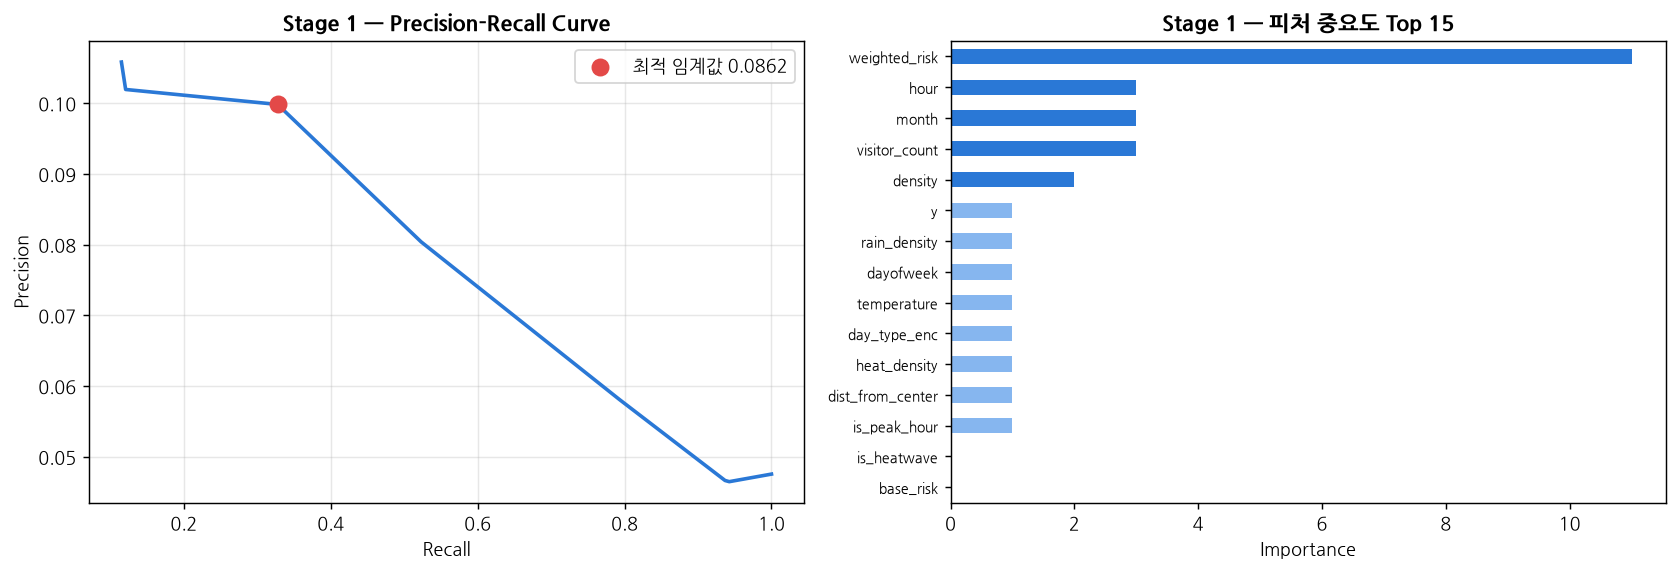

In [ ]:
# PR Curve + Feature Importance

> **해석**  
> - AUC **0.6288** — 무작위(0.5) 대비 응급 패턴 학습 확인  
> - 응급 Recall **35%** — 10건 중 약 3~4건 사전 탐지  
> - 응급 Precision **13%** — 알람의 87%는 위음성 → 임계값 조정 또는 추가 피처로 개선 가능  
> - 주요 피처: `weighted_risk`, `density_risk_ratio`, `base_risk`, `hour`


---
## 3. Stage 2 — 응급 유형 예측 (12종 다중 분류)

**대상**: 응급 발생 레코드만 (Train 581건, Test 81건)  
**모델**: LightGBM + `class_weight='balanced'`


In [ ]:
# Stage 2 성능 지표
print(f"Val  Accuracy : 0.2356")
print(f"Test Accuracy : 0.3086")
print(f"Test Macro-F1 : 0.294")
print(f"\n무작위 기준(1/12) : {1/12:.4f}")


Val  Accuracy : 0.2356
Test Accuracy : 0.3086
Test Macro-F1 : 0.294

무작위 기준(1/12) : 0.0833


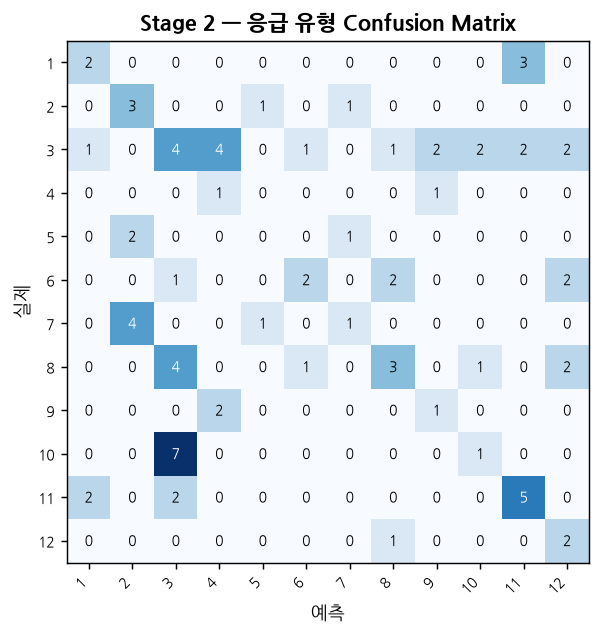

In [ ]:
# Confusion Matrix — 응급 유형

> **해석**  
> - 무작위(8.3%) 대비 **30.9%** 달성  
> - 학습 데이터 581건, 12종 — 클래스당 평균 약 48건으로 제한적  
> - 데이터 추가 확보 시 성능 향상 여지 큼


---
## 4. Stage 3 — 중증도 예측 (경증 / 중등증 / 중증)

**대상**: 응급 발생 레코드 / 학습 분포: 경증 351건 · 중등증 170건 · 중증 60건


In [ ]:
# Stage 3 성능 지표
print(f"Val  Accuracy : 0.4195")
print(f"Test Accuracy : 0.5062")
print(f"Test Macro-F1 : 0.3486")
print(f"\n무작위 기준(1/3) : {1/3:.4f}")


Val  Accuracy : 0.4195
Test Accuracy : 0.5062
Test Macro-F1 : 0.3486

무작위 기준(1/3) : 0.3333


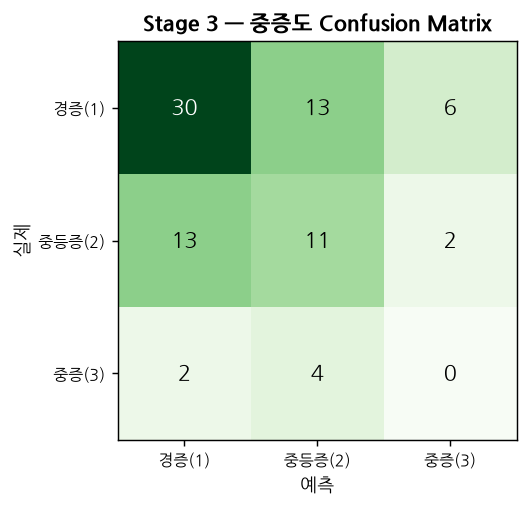

In [ ]:
# Confusion Matrix — 중증도

> **해석**  
> - 무작위(33.3%) 대비 **50.6%** — 3단계 중 가장 안정적  
> - Macro-F1 0.3486 — 경증 편중 데이터에서도 중등증·중증 포착  
> - 중증 예측 향상 시 위험도 스코어 정확도 직접 상승


---
## 5. 위험도 스코어 & 단계 분포

```
risk_score = P(응급) × (1 + E[중증도] / 5)    [0~1]
E[중증도]  = P(경증)×1.0 + P(중등증)×2.5 + P(중증)×5.0
```

| 단계 | 기준 | 대응 |
|---|---|---|
| 🔴 위험 | ≥ 0.15 | 즉각 대응팀 파견 · 119 대기 |
| 🟡 주의 | 0.07–0.15 | 예방 순찰 30분 강화 |
| 🔵 관찰 | 0.03–0.07 | 표준 모니터링 60분 |
| 🟢 안전 | < 0.03 | 정상 운영 |


In [ ]:
# 테스트셋 위험도 단계 분포
risk_dist = {'위험': 49, '주의': 1690, '관찰': 121, '안전': 0}
total = sum(risk_dist.values())
for k, v in risk_dist.items():
    print(f"  {k:4} : {v:5}건  ({v/total*100:.1f}%)")


  위험 :    49건  (2.6%)
  주의 :  1690건  (90.9%)
  관찰 :   121건  (6.5%)
  안전 :     0건  (0.0%)


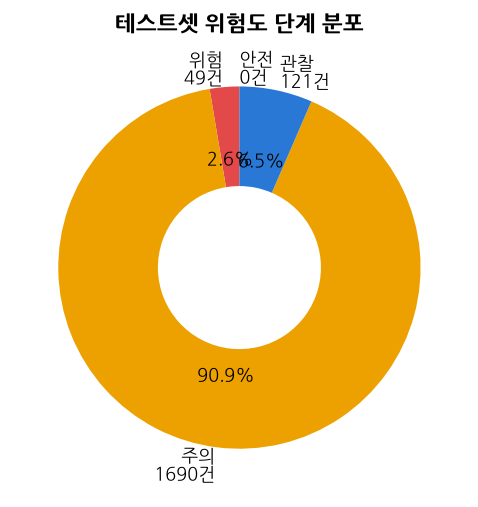

In [ ]:
# 위험도 단계 도넛 차트

---
## 6. 시설별 · 시간대별 위험도 & 자원 배치

기준일: **2026-07-31** (테스트셋 마지막 날)  
총 배치 인원: **6명** (시설당 최소 0.3명 보장 + 위험도 비례 추가)


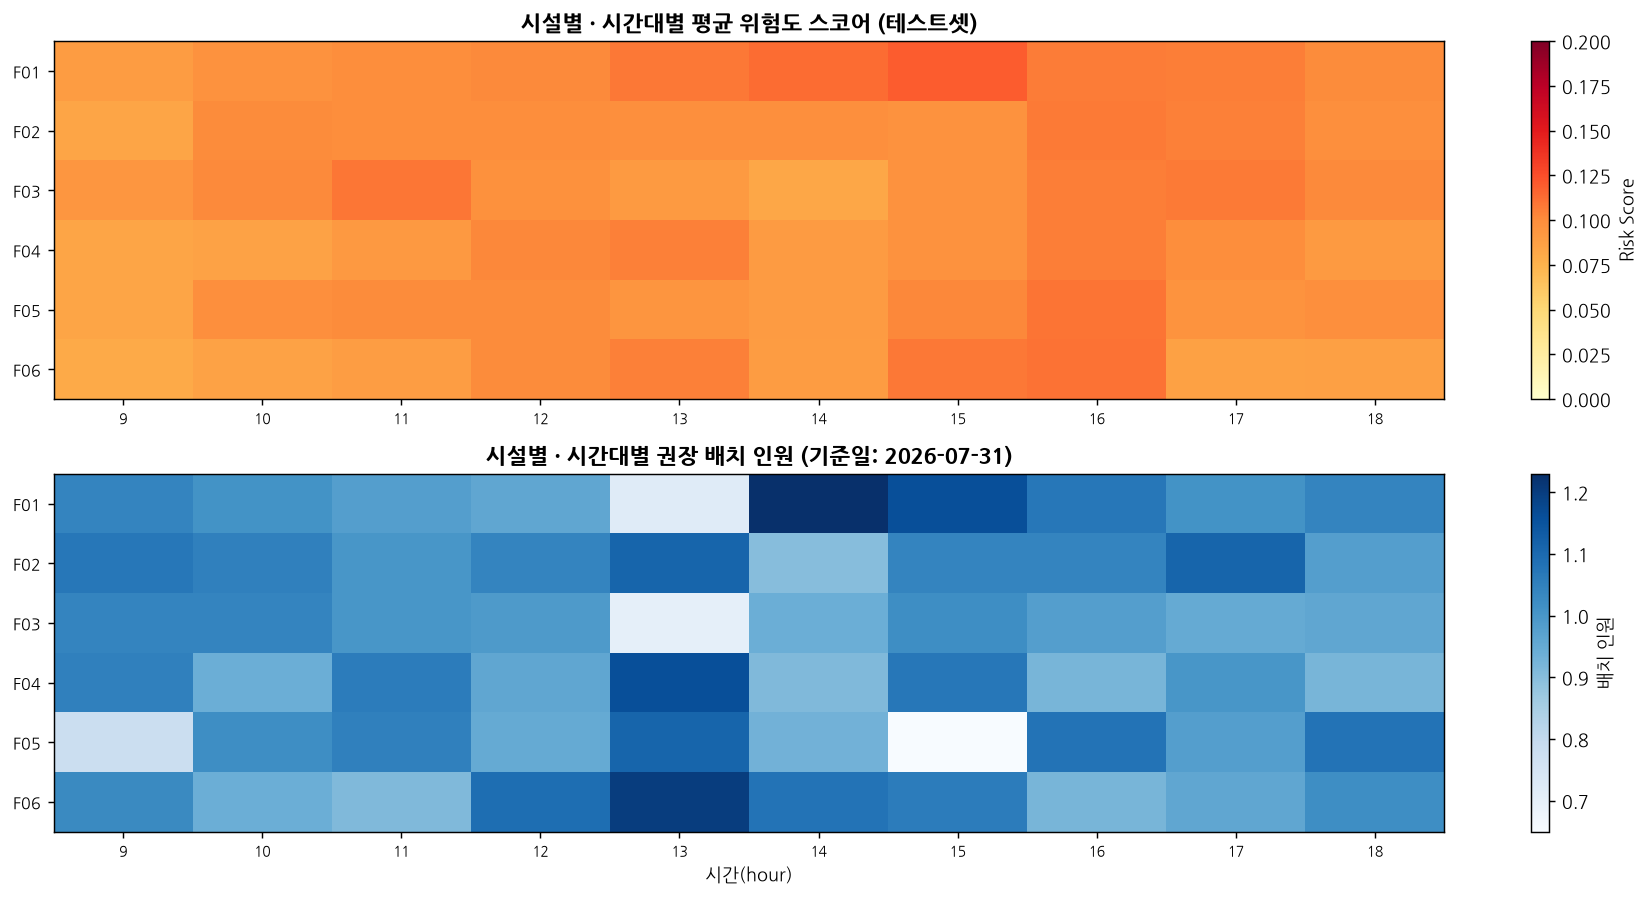

In [ ]:
# 위험도 히트맵 + 배치 인원

---
## 7. 모델 성능 종합 요약

| 단계 | 타깃 | 핵심 지표 | 값 | 무작위 대비 |
|---|---|---|---|---|
| Stage 1 | 응급 발생 (이진) | AUC | **0.6288** | +12.9%p |
| Stage 1 | 응급 발생 (이진) | Test F1 | **0.1898** | — |
| Stage 2 | 응급 유형 (12종) | Accuracy | **30.9%** | +22.5%p |
| Stage 3 | 중증도 (3단계) | Accuracy | **50.6%** | +17.3%p |

### 개선 방향
1. **Stage 1 Recall 향상**: 임계값 추가 하향 or SMOTE 오버샘플링
2. **Stage 2 데이터 확충**: 클래스당 48건 → 200건+ 확보 시 Accuracy 50%+ 기대
3. **피처 추가**: 이벤트 여부, 인근 응급실 거리, 요일×시즌 교호작용항
4. **앙상블**: XGBoost · CatBoost 결합으로 AUC 0.70+ 목표
